## Problem Set 1: The Business Challenge - Automated Ticket Routing

Imagine a large manufacturing company that operates two distinct divisions: **Automotive Parts** and **Medical Devices**. Every day, the customer support center receives thousands of unstructured text emails from clients.

Currently, human agents must manually read each email to decide whether to forward it to the Automotive team or the Medical team. This manual triage is slow, expensive, and leads to delayed response times. The goal is to build an automated NLP (Natural Language Processing) system that reads the raw text and instantly routes the ticket to the correct department.

---

### 1. Data Cleaning (Preprocessing)

Customers write messy emails containing typos, random numbers, and formatting issues. Before our automated system can make a routing decision, we must clean the data.

* **Standardization:** We lowercase all text so that "Engine" and "engine" are treated as the same part.
* **Noise Reduction:** We remove punctuation and numbers to focus purely on the textual intent.
* **Stopword Removal:** We filter out filler words (like "the", "is", "please", "help") that do not help distinguish between a medical or automotive issue.
* **Lemmatization:** We reduce words to their root form (e.g., converting "batteries" to "battery") to streamline our system's vocabulary.

---

### 2. Strategy 1: Keyword Tallying (Bag of Words)

To route the ticket, our first approach is Bag of Words (BoW). This is the equivalent of a simple keyword counting rule. The system scans the email and counts how many times specific words appear. If an email contains the word "car" two times and "transmission" once, the system recognizes these as automotive terms based on historical data and routes it accordingly.

* **Business Pro:** Very easy and cheap to implement for basic routing.
* **Business Con:** It is easily confused by phrasing and treats all words equally.

---

### 3. Strategy 2: Weighted Keyword Importance (TF-IDF)

Our second approach, TF-IDF (Term Frequency-Inverse Document Frequency), is a smarter business rule. In customer support, words like "broken" or "issue" might appear in almost every single ticket, regardless of the department. A basic Bag of Words model might give these words too much weight. TF-IDF solves this by penalizing overly common words and boosting the signal of unique, department-specific words (like "windshield" or "pacemaker").

* **Business Pro:** Highly effective at identifying the most critical keywords in a customer's complaint.
* **Business Con:** It still lacks an understanding of context or synonyms.

---

### 4. Strategy 3: Semantic Understanding (Word2Vec)

Our most advanced strategy uses Word Embeddings (Word2Vec). Instead of just matching exact keywords, this approach trains a neural network to understand the meaning and context of the customer's message. If a customer writes about a "physician," the Word2Vec model mathematically understands that this is closely related to "doctor" or "patient," even if those exact words were never explicitly written in the email. It averages the meaning of all the words in the email to grasp the overall intent.

* **Business Pro:** Captures deep nuance, making it highly robust for complex customer queries or varying terminologies.
* **Business Con:** Requires more computational power and historical data to train effectively.

---

### Measuring Business ROI (Model Evaluation)

To prove to stakeholders that the automated routing system works, we track specific Key Performance Indicators (KPIs) against a test batch of historical emails:

* **Accuracy:** Out of 1,000 incoming emails, what percentage did the system route to the correct department overall?
* **Precision:** When the AI routed an email to the Medical team, how often was it actually a medical issue? (Important for measuring misallocated resources).
* **Recall:** Out of all the true Medical issues that came in, how many did the system successfully catch? (Important for ensuring critical tickets don't get lost in the wrong queue).
* **Confusion Matrix:** A visual dashboard showing exactly where the system is making mistakes (e.g., how many Auto tickets were accidentally sent to Medical).

---

### Extra Student Assignments

#### Assignment 1: Hyperparameter Exploration (Beginner)
* **The Task:** Ask the students to change the `max_features` parameter in the `CountVectorizer` and `TfidfVectorizer` from 2000 to 100, 500, and 5000.
* **The Goal:** Have them re-run the classification models and observe how the Accuracy and F1-score change.
* **Learning Outcome:** Students will learn the trade-off between having a rich vocabulary (better accuracy) and the curse of dimensionality (overfitting and slower processing times).

#### Assignment 2: The Power of Phrases using N-grams (Intermediate)
* **The Task:** Instruct students to modify the `TfidfVectorizer` to include bi-grams (two-word combinations) by setting the parameter `ngram_range=(1, 2)`.
* **The Goal:** Have them check if capturing phrases like "steering wheel" or "blood pressure" improves the model's accuracy compared to relying on single words alone.
* **Learning Outcome:** Students will understand that word order matters in business contexts (e.g., "not broken" vs. "broken") and how N-grams partially solve the limitations of standard Bag of Words.

#### Assignment 3: Qualitative Error Analysis (Advanced)
* **The Task:** Have students write a Python script to isolate the False Positives and False Negatives from the TF-IDF predictions. Ask them to print out the raw text of 5 emails that the model routed incorrectly.
* **The Goal:** Manually read these failed emails and write a short paragraph explaining why the AI might have been confused.
* **Learning Outcome:** This bridges the gap between math and real-world logic. Students might discover that a customer talking about the "anatomy of a car engine" confuses the Medical model due to the word "anatomy."

#### Assignment 4: Using Pre-trained Embeddings (Advanced)
* **The Task:** Instead of training a Word2Vec model from scratch on this small dataset, use the `gensim.downloader` API to download a pre-trained embedding model (e.g., `glove-twitter-25` or `word2vec-google-news-300`).
* **The Goal:** Build the document vectors using these massive pre-trained models and run the Gaussian Naive Bayes classifier again.
* **Learning Outcome:** Students will experience Transfer Learning and see how leveraging models trained by Google or Stanford on billions of words can instantly upgrade their own application.

# Comprehensive Guide to Text Representation & Classification 📚

Welcome to this interactive notebook! In this lesson, we will explore **Natural Language Processing (NLP)**, specifically focusing on how machines understand text.

## Learning Objectives
By the end of this notebook, you will be able to:
* Understand different methods of converting text into numerical features.
* Learn the difference between **Bag of Words**, **TF-IDF**, and **Word2Vec** embeddings.
* Build and evaluate a Naive Bayes text classification model using different text representations.
* Compare the performance of different text embedding techniques.

---

## 1. Introduction

### Brief Introduction to NLP
Natural Language Processing (NLP) is a branch of Artificial Intelligence (AI) that helps computers understand, interpret, and manipulate human language. Applications include spam detection, sentiment analysis, machine translation, and chatbots.

### Why Machines Cannot Understand Raw Text
Machine learning models (like Neural Networks or Naive Bayes) are mathematical functions. They expect numbers (matrices and vectors) as input, not strings like `"Hello world!"`.

> **Key Insight:** Before we can train a model to classify text, we must first convert the text into numerical representations. This process is called **Text Vectorization** or **Feature Extraction**.

### Overview of Embedding Techniques
We will cover three foundational techniques:
1.  **Bag of Words (BoW):** Counts the frequency of words in a document. Simple, but ignores word order and meaning.
2.  **TF-IDF (Term Frequency-Inverse Document Frequency):** Weighs words by how common they are in a document vs. the whole corpus. Better than BoW at identifying "important" words.
3.  **Word2Vec (Word Embeddings):** Uses a shallow neural network to learn word associations. Captures deep semantic meaning (e.g., understands that "king" and "queen" are related).
    


In [ ]:
import os
os.makedirs(os.path.expanduser('~/scikit_learn_data'), exist_ok=True)

!wget -q http://qwone.com/~jason/20Newsgroups/20news-bydate.tar.gz -O ~/scikit_learn_data/20news-bydate.tar.gz

In [ ]:
!pip install gensim

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import gensim
from gensim.models import Word2Vec

# Set notebook configurations
warnings.filterwarnings('ignore')
np.random.seed(42) # Set seed for reproducibility
sns.set_theme(style="whitegrid")

# Download required NLTK datasets (run once)
nltk.download('punkt_tab')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('omw-1.4')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Dataset Setup

For this notebook, we will use a classic text classification dataset: the **20 Newsgroups Dataset** (available natively via Scikit-Learn).
To make it simple and simulate a binary classification task (like Spam vs Ham), we will fetch only two distinct categories:
1.  **Medical Science** (`sci.med`)
2.  **Automobiles** (`rec.autos`)

* **Input Features ($X$):** The raw text of the newsgroup post.
* **Target Labels ($y$):** The category to which the post belongs (0 for Autos, 1 for Medical).
    


In [ ]:
# # Load the dataset (fetching 2 specific categories)
# categories = ['rec.autos', 'sci.med']
# newsgroups = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

# # Create a Pandas DataFrame for easier manipulation
# df = pd.DataFrame({'text': newsgroups.data, 'label': newsgroups.target})

# # Map labels to meaningful names
# label_mapping = {0: 'Autos', 1: 'Medical'}
# df['category'] = df['label'].map(label_mapping)

# display(df.head(5))

# # Remove empty texts (some documents become empty after removing headers/footers)
# df = df[df['text'].str.strip().astype(bool)].reset_index(drop=True)

# print(f"Total dataset size: {df.shape[0]} documents\n")

# # Display a sample record
# print("--- Sample Text (Input Feature) ---")
# print(df['text'].iloc[0][:500], "...\n")
# print(f"--- Target Label: {df['category'].iloc[0]} ---\n")

# # Plot Class Distribution
# plt.figure(figsize=(6, 4))
# sns.countplot(data=df, x='category', palette='pastel')
# plt.title('Class Distribution of Dataset')
# plt.xlabel('Category')
# plt.ylabel('Number of Documents')
# plt.show()



### In case there is an 403 Forbidden error in sklearn.datasets.fetch_20newsgroups

Repo card metadata block was not found. Setting CardData to empty.


,text,label,category
0,I was wondering if anyone out there could enli...,0,Autos
1,There were a few people who responded to my re...,1,Medical
2,I recently posted an article asking what kind ...,0,Autos
3,\nIt depends on your priorities. A lot of peo...,0,Autos
4,My 14-y-o son has the usual teenage spotty chi...,1,Medical


Total dataset size: 1140 documents

--- Sample Text (Input Feature) ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail. ...

--- Target Label: Autos ---



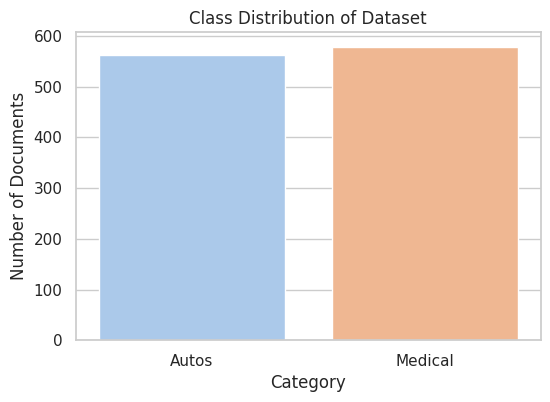

In [ ]:
# Load the dataset (fetching 2 specific categories)
from datasets import load_dataset

categories = ['rec.autos', 'sci.med']
ds = load_dataset("SetFit/20_newsgroups")

# Create a Pandas DataFrame for easier manipulation
df = pd.DataFrame(ds['train'])
df = df[df['label_text'].isin(categories)].reset_index(drop=True)

# Map labels to meaningful names
label_mapping = {'rec.autos': 0, 'sci.med': 1}
category_mapping = {0: 'Autos', 1: 'Medical'}
df['label'] = df['label_text'].map(label_mapping)
df['category'] = df['label'].map(category_mapping)
df = df[['text', 'label', 'category']]

display(df.head(5))

# Remove empty texts (some documents become empty after removing headers/footers)
df = df[df['text'].str.strip().astype(bool)].reset_index(drop=True)

print(f"Total dataset size: {df.shape[0]} documents\n")

# Display a sample record
print("--- Sample Text (Input Feature) ---")
print(df['text'].iloc[0][:500], "...\n")
print(f"--- Target Label: {df['category'].iloc[0]} ---\n")

# Plot Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='category', palette='pastel')
plt.title('Class Distribution of Dataset')
plt.xlabel('Category')
plt.ylabel('Number of Documents')
plt.show()

## 3. Data Preprocessing

Raw text is messy. It contains punctuation, capital letters, HTML tags, and common words (like 'the', 'is', 'and') that don't add much meaning to the classification task.

We will implement a function to clean our text. The steps include:
* **Lowercasing:** `Python`, `python`, and `PYTHON` should all be treated as the same word.
* **Removing punctuation & numbers:** We want to focus purely on alphabetic words.
* **Tokenization:** Breaking down a sentence into a list of individual words (tokens).
* **Stopword removal:** Filtering out common words (e.g., "is", "the", "a") that carry no semantic weight.
* **Lemmatization:** Converting words to their base dictionary form (e.g., "running" -> "run", "better" -> "good").

> **Tip:** Preprocessing is often the most critical step in NLP. Garbage in, garbage out!
    


In [ ]:
# Initialize Lemmatizer and Stopwords list
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase text
    text = text.lower()
    # 2. Remove punctuation and numbers using Regex (keep only letters)
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenization
    tokens = word_tokenize(text)
    # 4. Stopword removal & 5. Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Return as a joined string for BoW/TF-IDF, and as a list for Word2Vec later
    return ' '.join(cleaned_tokens), cleaned_tokens

# Apply preprocessing
# Unzip the results into two columns: one string format, one list format
df['clean_text'], df['tokens'] = zip(*df['text'].apply(preprocess_text))

# Remove documents that became empty after cleaning
df = df[df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)

# Show Before vs After
print("BEFORE PREPROCESSING:")
print(df['text'].iloc[0][:200].strip(), "...\n")
print("AFTER PREPROCESSING:")
print(df['clean_text'].iloc[0][:200].strip(), "...\n")



BEFORE PREPROCESSING:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were ...

AFTER PREPROCESSING:
wondering anyone could enlighten car saw day door sport car looked late early called bricklin door really small addition front bumper separate rest body know anyone tellme model name engine spec year ...



## 4. Bag of Words (BoW)

### Definition
Bag of Words is one of the simplest text representation techniques. It creates a "vocabulary" of all unique words in the dataset and represents each document based on the **frequency (count)** of these words.

### How it works
1. **Vocabulary Creation:** Gather all unique words across all documents.
2. **Scoring:** For each document, count how many times each word from the vocabulary appears.

### Example
* Doc 1: "The cat sat on the mat"
* Doc 2: "The dog sat on the log"
* **Vocabulary:** `[the, cat, sat, on, mat, dog, log]`
* **Doc 1 Vector:** `[2, 1, 1, 1, 1, 0, 0]` (Notice "the" appears twice).

> **Note - Sparse Matrix Representation:** Since the overall vocabulary might have 10,000 words, but a single document only contains 20 words, the resulting vector is mostly zeros. Scikit-learn handles this efficiently using **Sparse Matrices** to save memory.

### Advantages & Limitations
* ✅ **Advantages:** Very simple to implement, intuitive, and works surprisingly well for basic classification.
* ❌ **Limitations:** Ignores word order ("not good" vs "good not"). Ignores semantics (doesn't know "car" and "automobile" are similar). Creates massive, highly sparse feature spaces.
    


BoW Feature Matrix Shape: (1140, 2000)
(This means we have 1140 documents and a vocabulary of 2000 words)

Sample Vocabulary (Word -> Index Mapping):
{'wondering': np.int64(1965), 'anyone': np.int64(88), 'could': np.int64(383), 'car': np.int64(242), 'saw': np.int64(1536), 'day': np.int64(417), 'door': np.int64(501), 'sport': np.int64(1670), 'looked': np.int64(1007), 'late': np.int64(957)} 



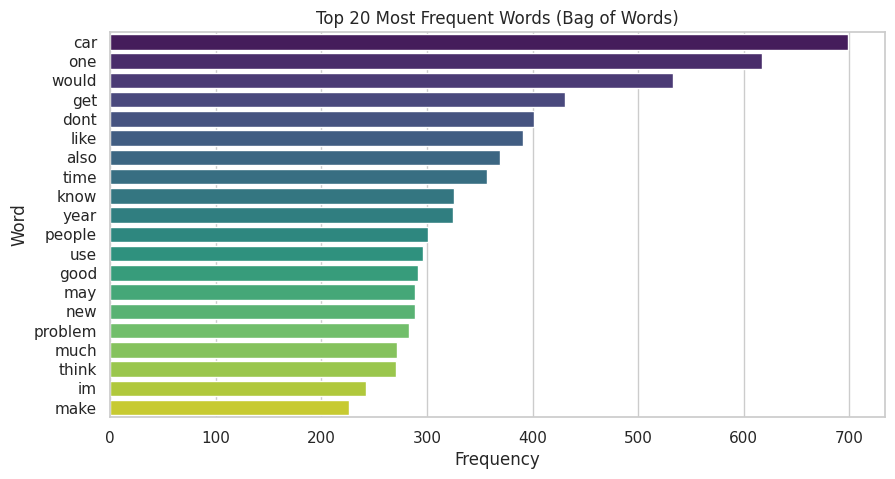

In [ ]:
# Initialize CountVectorizer (Bag of Words)
# max_features restricts the vocabulary to the top 2000 most frequent words to avoid memory issues
vectorizer_bow = CountVectorizer(max_features=2000)

# Fit and transform the clean text
X_bow = vectorizer_bow.fit_transform(df['clean_text'])
y = df['label'].values

print(f"BoW Feature Matrix Shape: {X_bow.shape}")
print(f"(This means we have {X_bow.shape[0]} documents and a vocabulary of {X_bow.shape[1]} words)\n")

# Display a slice of the vocabulary mapping
vocab = vectorizer_bow.vocabulary_
print("Sample Vocabulary (Word -> Index Mapping):")
sample_vocab = {k: vocab[k] for k in list(vocab)[:10]}
print(sample_vocab, "\n")

# Let's visualize the top 20 most frequent words in our dataset
word_counts = X_bow.sum(axis=0)
word_freq = [(word, word_counts[0, idx]) for word, idx in vocab.items()]
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Most Frequent Words (Bag of Words)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()



## 5. Text Classification using Bag of Words

Now that we have numerical vectors, we can train a Machine Learning model.
We will split our data into a Training set and a Testing set. We'll use a **Multinomial Naive Bayes** classifier, which is perfectly suited for discrete count data like BoW.

### Evaluation Metrics Explanation
* **Accuracy:** Overall percentage of correct predictions.
* **Precision:** Out of all documents predicted as "Medical", how many were actually Medical? (Quality)
* **Recall:** Out of all actual "Medical" documents, how many did we successfully find? (Quantity)
* **F1-score:** The harmonic mean of Precision and Recall. Best when you need a balance between the two.
* **Confusion Matrix:** A grid showing True Positives, True Negatives, False Positives, and False Negatives.
    


--- Bag of Words Model Performance ---
Accuracy:  0.9474
Precision: 0.9633
Recall:    0.9292
F1-score:  0.9459



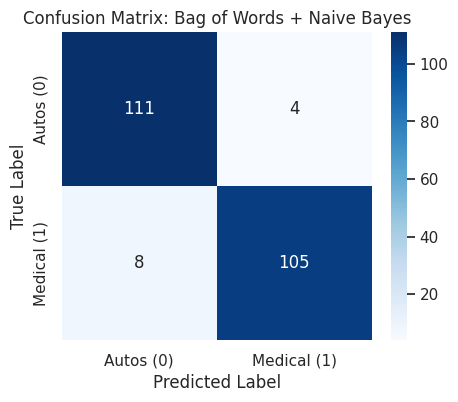

In [ ]:
# 1. Train/Test Split
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)

# 2. Train Multinomial Naive Bayes Classifier
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

# 3. Predict on test data
y_pred_bow = nb_bow.predict(X_test_bow)

# 4. Evaluate
acc_bow = accuracy_score(y_test, y_pred_bow)
prec_bow = precision_score(y_test, y_pred_bow)
rec_bow = recall_score(y_test, y_pred_bow)
f1_bow = f1_score(y_test, y_pred_bow)

print(f"--- Bag of Words Model Performance ---")
print(f"Accuracy:  {acc_bow:.4f}")
print(f"Precision: {prec_bow:.4f}")
print(f"Recall:    {rec_bow:.4f}")
print(f"F1-score:  {f1_bow:.4f}\n")

# 5. Confusion Matrix Visualization
cm_bow = confusion_matrix(y_test, y_pred_bow)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Autos (0)', 'Medical (1)'],
            yticklabels=['Autos (0)', 'Medical (1)'])
plt.title('Confusion Matrix: Bag of Words + Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



## 6. TF-IDF Encoding

### Definition
**TF-IDF (Term Frequency - Inverse Document Frequency)** is an improvement over BoW.
BoW treats all words equally. This means a word that appears frequently in *every* document (like "people" or "time") gets a high score, even if it doesn't help distinguish between categories. TF-IDF fixes this.

### How it Works
1.  **Term Frequency (TF):** How often does the word appear in *this specific document*?
    $TF = \frac{\text{Count of word in doc}}{\text{Total words in doc}}$
2.  **Inverse Document Frequency (IDF):** How rare is the word across *all documents*?
    $IDF = \log(\frac{\text{Total number of docs}}{\text{Number of docs containing the word}})$
3.  **TF-IDF Score:** $TF \times IDF$

> **Key Insight:** A word gets a high TF-IDF score if it appears frequently in a document (High TF), but rarely across the whole corpus (High IDF). It penalizes overly common words.

### Advantages & Limitations
* ✅ **Advantages:** Highlights important keywords natively. Better performance than BoW for classification.
* ❌ **Limitations:** Still ignores word order. Still cannot capture semantic similarity between synonyms. Highly sparse.
    


In [ ]:
# Initialize TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(max_features=2000)

# Fit and transform the clean text
X_tfidf = vectorizer_tfidf.fit_transform(df['clean_text'])

print(f"TF-IDF Feature Matrix Shape: {X_tfidf.shape}")

# Let's see the TF-IDF values for the first document
doc_0_tfidf = pd.DataFrame(X_tfidf[0].T.todense(),
                           index=vectorizer_tfidf.get_feature_names_out(),
                           columns=["TF-IDF Score"])

# Sort to see the words with the highest TF-IDF score in Document 0
print("\nTop 5 Words in Document 0 by TF-IDF Score:")
print(doc_0_tfidf.sort_values(by="TF-IDF Score", ascending=False).head(5))



TF-IDF Feature Matrix Shape: (1140, 2000)

Top 5 Words in Document 0 by TF-IDF Score:
          TF-IDF Score
car           0.339174
door          0.323023
anyone        0.211148
spec          0.206305
separate      0.199219


## 7. Text Classification using TF-IDF

Let's repeat our machine learning pipeline, this time using the TF-IDF feature matrix.
    


--- TF-IDF Model Performance ---
Accuracy:  0.9561
Precision: 0.9725
Recall:    0.9381
F1-score:  0.9550



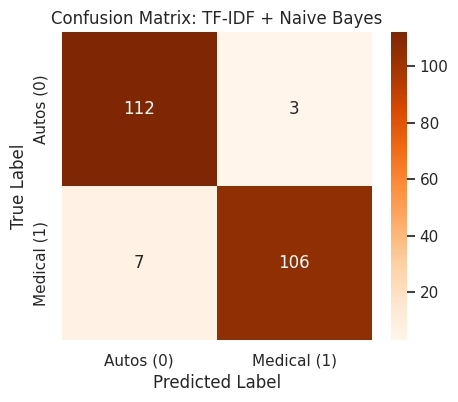

In [ ]:
# 1. Train/Test Split (Use the same split indices for fair comparison)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 2. Train Classifier
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

# 3. Predict
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

# 4. Evaluate
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
prec_tfidf = precision_score(y_test, y_pred_tfidf)
rec_tfidf = recall_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf)

print(f"--- TF-IDF Model Performance ---")
print(f"Accuracy:  {acc_tfidf:.4f}")
print(f"Precision: {prec_tfidf:.4f}")
print(f"Recall:    {rec_tfidf:.4f}")
print(f"F1-score:  {f1_tfidf:.4f}\n")

# 5. Confusion Matrix Visualization
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Autos (0)', 'Medical (1)'],
            yticklabels=['Autos (0)', 'Medical (1)'])
plt.title('Confusion Matrix: TF-IDF + Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



## 8. Word Embeddings

### Why BoW and TF-IDF are not enough
Both BoW and TF-IDF rely on exact string matching. If Document A uses the word "doctor" and Document B uses "physician", BoW/TF-IDF treat them as 100% completely different words. They have zero understanding of **Semantic Meaning**.

### Distributed Representations
Embeddings represent words as dense, continuous vectors of numbers (e.g., 100 dimensions) where geometrically close vectors represent semantically similar words.

### What is Word2Vec?
Word2Vec is a predictive embedding model developed by Google. It uses a shallow, two-layer neural network trained on massive amounts of text to reconstruct linguistic contexts of words.
* **CBOW (Continuous Bag-of-Words):** Predicts a target word based on its surrounding context words.
* **Skip-Gram:** Predicts surrounding context words given a target word.

> **Visual Example:**
> In embedding space: `Vector("King") - Vector("Man") + Vector("Woman") ≈ Vector("Queen")`

### Advantages & Limitations
* ✅ **Advantages:** Captures rich semantic meaning. Dense vectors (no sparsity). Dimensionality is fixed (e.g., 100) regardless of vocabulary size.
* ❌ **Limitations:** Out-of-vocabulary (OOV) problem (cannot embed words it wasn't trained on). Standard Word2Vec cannot handle context (e.g., "apple" the fruit vs "Apple" the company have the exact same vector).
    


## 9. Training a Word2Vec Model

We will use the `gensim` library to train a Word2Vec model from scratch using our tokenized dataset.
    


In [ ]:
display(df.head())

,text,label,category,clean_text,tokens
0,I was wondering if anyone out there could enli...,0,Autos,wondering anyone could enlighten car saw day d...,"[wondering, anyone, could, enlighten, car, saw..."
1,There were a few people who responded to my re...,1,Medical,people responded request info treatment astroc...,"[people, responded, request, info, treatment, ..."
2,I recently posted an article asking what kind ...,0,Autos,recently posted article asking kind rate singl...,"[recently, posted, article, asking, kind, rate..."
3,\nIt depends on your priorities. A lot of peo...,0,Autos,depends priority lot people put higher priorit...,"[depends, priority, lot, people, put, higher, ..."
4,My 14-y-o son has the usual teenage spotty chi...,1,Medical,yo son usual teenage spotty chin greasy nose b...,"[yo, son, usual, teenage, spotty, chin, greasy..."


In [ ]:
# Important Hyperparameters:
# sentences: Iterable of lists of tokens
# vector_size: Dimensionality of the word vectors
# window: Maximum distance between current and predicted word within a sentence
# min_count: Ignores all words with total frequency lower than this
# workers: Number of worker threads to train the model

print("Training Word2Vec model...")
w2v_model = Word2Vec(sentences=df['tokens'],
                     vector_size=100,
                     window=5,
                     min_count=5,
                     workers=4,
                     sg=0, # sg=0 means CBOW, sg=1 means Skip-Gram
                     seed=42)
print("Training Complete!")

# View vocabulary size
vocab_size = len(w2v_model.wv)
print(f"Word2Vec Vocabulary Size: {vocab_size} words\n")

# Show word vector for a specific word
word = "car"
if word in w2v_model.wv:
    print(f"Vector for '{word}' (First 5 dimensions of 100):")
    print(w2v_model.wv[word][:5], "...\n")

    # Semantic Similarity: Most similar words
    print(f"Words most similar to '{word}':")
    for sim_word, score in w2v_model.wv.most_similar(word, topn=5):
        print(f" - {sim_word}: {score:.4f}")
else:
    print(f"'{word}' not in vocabulary.")

print("\n")
word2 = "patient"
if word2 in w2v_model.wv:
    print(f"Words most similar to '{word2}':")
    for sim_word, score in w2v_model.wv.most_similar(word2, topn=5):
        print(f" - {sim_word}: {score:.4f}")



Training Word2Vec model...
Training Complete!
Word2Vec Vocabulary Size: 3489 words

Vector for 'car' (First 5 dimensions of 100):
[ 0.2573772  -0.26142895 -0.44970325  0.10708769 -0.55610824] ...

Words most similar to 'car':
 - see: 0.9997
 - think: 0.9997
 - one: 0.9997
 - would: 0.9997
 - get: 0.9996


Words most similar to 'patient':
 - two: 0.9997
 - without: 0.9997
 - many: 0.9997
 - also: 0.9997
 - say: 0.9997


## 10. Document Embedding (Sentence/Document Level)

Word2Vec gives us a vector for *individual words*. But text classification requires a single vector for the *entire document*.

### How do we convert Word Vectors to Document Vectors?
The simplest, most common baseline approach is **Averaging**.
For a document containing words $(W_1, W_2, W_3)$, the document vector is:
$$\text{DocVec} = \frac{W_1 + W_2 + W_3}{3}$$

> **Why Averaging?** Averaging acts as a composition function. It combines the semantic meaning of all words in the sentence into a single point in the embedding space.
    


In [ ]:
def get_document_vector(tokens, model):
    """
    Calculates the document vector by averaging the word vectors of its tokens.
    """
    # Filter tokens to only those that exist in the Word2Vec vocabulary
    valid_tokens = [word for word in tokens if word in model.wv.key_to_index]

    if not valid_tokens:
        # If no valid words found, return a vector of zeros
        return np.zeros(model.vector_size)

    # Retrieve vectors and calculate the mean along the columns (axis=0)
    word_vectors = np.array([model.wv[word] for word in valid_tokens])
    doc_vector = np.mean(word_vectors, axis=0)

    return doc_vector

# Generate document embeddings for the entire dataset
X_w2v = np.array([get_document_vector(tokens, w2v_model) for tokens in df['tokens']])

print(f"Document Embeddings Matrix Shape: {X_w2v.shape}")
print(f"(We have {X_w2v.shape[0]} documents, each represented by a {X_w2v.shape[1]}-dimensional dense vector)")



Document Embeddings Matrix Shape: (1140, 100)
(We have 1140 documents, each represented by a 100-dimensional dense vector)


## 11. Text Classification using Word2Vec

Let's train a classifier on our new dense document vectors.

> **Important Note:** We cannot use `Multinomial Naive Bayes` here. Multinomial NB is designed for discrete counts (like BoW) or fractional counts (like TF-IDF) and strictly cannot accept negative values. Word2Vec vectors are continuous real numbers containing negative values. Therefore, we switch to **Gaussian Naive Bayes**, which assumes features follow a normal distribution.
    


--- Word2Vec Model Performance ---
Accuracy:  0.5526
Precision: 0.7391
Recall:    0.1504
F1-score:  0.2500



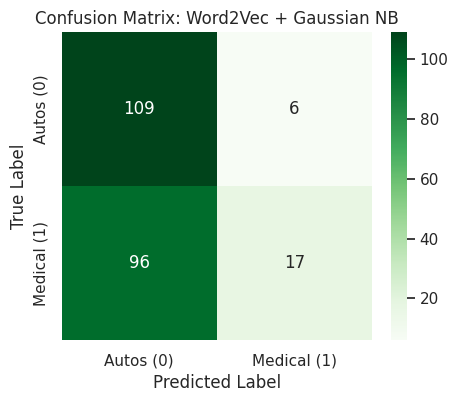

In [ ]:
# 1. Train/Test Split
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

# 2. Train Gaussian Naive Bayes Classifier
nb_w2v = GaussianNB()
nb_w2v.fit(X_train_w2v, y_train)

# 3. Predict
y_pred_w2v = nb_w2v.predict(X_test_w2v)

# 4. Evaluate
acc_w2v = accuracy_score(y_test, y_pred_w2v)
prec_w2v = precision_score(y_test, y_pred_w2v)
rec_w2v = recall_score(y_test, y_pred_w2v)
f1_w2v = f1_score(y_test, y_pred_w2v)

print(f"--- Word2Vec Model Performance ---")
print(f"Accuracy:  {acc_w2v:.4f}")
print(f"Precision: {prec_w2v:.4f}")
print(f"Recall:    {rec_w2v:.4f}")
print(f"F1-score:  {f1_w2v:.4f}\n")

# 5. Confusion Matrix Visualization
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Autos (0)', 'Medical (1)'],
            yticklabels=['Autos (0)', 'Medical (1)'])
plt.title('Confusion Matrix: Word2Vec + Gaussian NB')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



## 12. Performance Comparison

Let's compile our results and visualize them.
    


,Method,Feature Type,Naive Bayes Variant,Accuracy,Precision,Recall,F1-score
0,Bag of Words,"Sparse, Count",Multinomial,0.947368,0.963303,0.929204,0.945946
1,TF-IDF,"Sparse, Weighted",Multinomial,0.956140,0.972477,0.938053,0.954955
2,Word2Vec (Averaged),"Dense, Continuous",Gaussian,0.552632,0.739130,0.150442,0.250000


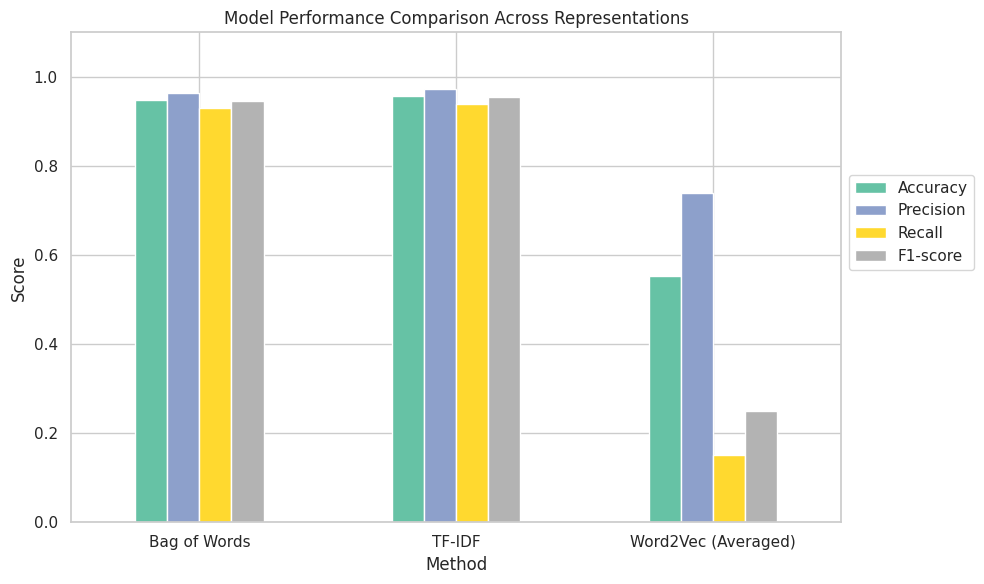

In [ ]:
# Create a summary DataFrame
results = {
    'Method': ['Bag of Words', 'TF-IDF', 'Word2Vec (Averaged)'],
    'Feature Type': ['Sparse, Count', 'Sparse, Weighted', 'Dense, Continuous'],
    'Naive Bayes Variant': ['Multinomial', 'Multinomial', 'Gaussian'],
    'Accuracy': [acc_bow, acc_tfidf, acc_w2v],
    'Precision': [prec_bow, prec_tfidf, prec_w2v],
    'Recall': [rec_bow, rec_tfidf, rec_w2v],
    'F1-score': [f1_bow, f1_tfidf, f1_w2v]
}

results_df = pd.DataFrame(results)
display(results_df)

# Visualize Comparison
results_df.set_index('Method')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Model Performance Comparison Across Representations')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()



### Discussion
* **BoW & TF-IDF** often perform incredibly well on simple topic classification tasks because specific keywords (like "engine" or "disease") are dead giveaways for the category. TF-IDF usually edges out BoW by penalizing noise words.
* **Word2Vec** trained from scratch on a small dataset might underperform. Word2Vec shines when trained on millions of documents (or when using pre-trained embeddings like GloVe or GoogleNews vectors) because it understands nuance. However, simple averaging of word vectors can also wash out important keywords.

---

## 13. Key Takeaways

1.  **When to use Bag of Words?**
    * When you need a quick, simple baseline.
    * When the task is simple and heavily reliant on specific vocabulary.
2.  **When to use TF-IDF?**
    * Almost always preferred over raw BoW.
    * Excellent for traditional machine learning algorithms (Naive Bayes, SVM, Logistic Regression).
    * Great for document retrieval and keyword extraction.
3.  **When to use Word2Vec?**
    * When semantic meaning is crucial (e.g., Sentiment analysis, finding similar documents, chatbots).
    * When feeding data into deep learning architectures (RNNs, LSTMs, Transformers).
    * *Practical tip:* Use pre-trained embeddings rather than training from scratch unless you have a highly specialized domain (like obscure medical literature).
    
Happy learning! 🚀
    
